In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
df = pd.read_csv("customer_transactions.csv", parse_dates=["invoice_date"])
df = df.drop_duplicates().reset_index(drop=True)
df = df[df["purchase_amount"] > 0]

print(f"Transactions: {df.shape[0]}, Unique customers: {df['customer_id'].nunique()}")
df.head()


Transactions: 9999, Unique customers: 1000


,customer_id,invoice_id,invoice_date,purchase_amount,product_category,payment_method,customer_segment,region
0,CUST_102,INV_0,2024-01-23,71.39,Clothing,UPI,Loyal,North
1,CUST_435,INV_1,2024-02-23,56.88,Clothing,Credit Card,Returning,South
2,CUST_860,INV_2,2024-03-05,89.96,Electronics,Cash on Delivery,Loyal,East
3,CUST_270,INV_3,2024-05-19,26.58,Beauty,Cash on Delivery,New,South
4,CUST_106,INV_4,2024-01-24,283.46,Books,Credit Card,Returning,North


## RFM Analysis
For each customer we compute:
- **Recency** — days since their most recent purchase (relative to a snapshot date)
- **Frequency** — number of transactions
- **Monetary** — total amount spent

These three metrics are the backbone of RFM segmentation, a standard technique for identifying high-value customers.

In [5]:
snapshot_date = df["invoice_date"].max() + pd.Timedelta(days=1)

rfm = df.groupby("customer_id").agg(
    recency=("invoice_date", lambda x: (snapshot_date - x.max()).days),
    frequency=("invoice_id", "count"),
    monetary=("purchase_amount", "sum"),
    avg_purchase_amount=("purchase_amount", "mean"),
    first_purchase=("invoice_date", "min"),
    last_purchase=("invoice_date", "max"),
).reset_index()

rfm["tenure_days"] = (rfm["last_purchase"] - rfm["first_purchase"]).dt.days

# Most frequent categorical attributes per customer (useful as model features later)
mode_cols = ["product_category", "payment_method", "customer_segment", "region"]
modes = df.groupby("customer_id")[mode_cols].agg(lambda x: x.mode().iloc[0]).reset_index()
rfm = rfm.merge(modes, on="customer_id", how="left")

print(f"Customer-level RFM table: {rfm.shape}")
rfm.head()


Customer-level RFM table: (1000, 12)


,customer_id,recency,frequency,monetary,avg_purchase_amount,first_purchase,last_purchase,tenure_days,product_category,payment_method,customer_segment,region
0,CUST_0,21,16,944.31,59.019375,2024-02-02,2024-06-08,127,Electronics,Debit Card,Loyal,North
1,CUST_1,5,9,1418.52,157.613333,2024-01-18,2024-06-24,158,Electronics,UPI,New,West
2,CUST_10,12,6,347.41,57.901667,2024-01-18,2024-06-17,151,Beauty,Debit Card,Returning,East
3,CUST_100,13,11,1127.27,102.479091,2024-01-01,2024-06-16,167,Home,UPI,Returning,East
4,CUST_101,1,11,642.11,58.373636,2024-01-24,2024-06-28,156,Books,UPI,Loyal,West


### RFM scoring & segmentation

Each of Recency, Frequency, and Monetary is bucketed into quartiles (1-4, with 4 = best), then summed into an
`RFM_score`. Customers are grouped into business-friendly segments based on that score:

| RFM score | Segment |
|---|---|
| 10-12 | Champions |
| 8-9 | Loyal Customers |
| 6-7 | Potential Loyalists |
| 4-5 | At Risk |
| 3 | Lost |


In [6]:
r_labels, f_labels, m_labels = range(4, 0, -1), range(1, 5), range(1, 5)

# Recency: lower is better, so labels are reversed
rfm["R"] = pd.qcut(rfm["recency"], 4, labels=r_labels).astype(int)
# rank(method="first") avoids errors from duplicate bin edges on the frequency column
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=f_labels).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"], 4, labels=m_labels).astype(int)

rfm["RFM_score"] = rfm["R"] + rfm["F"] + rfm["M"]

def assign_segment(score):
    if score >= 10:
        return "Champions"
    elif score >= 8:
        return "Loyal Customers"
    elif score >= 6:
        return "Potential Loyalists"
    elif score >= 4:
        return "At Risk"
    else:
        return "Lost"

rfm["rfm_segment"] = rfm["RFM_score"].apply(assign_segment)

segment_summary = rfm.groupby("rfm_segment").agg(
    customers=("customer_id", "count"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean"),
).round(1).sort_values("avg_monetary", ascending=False)

segment_summary


,customers,avg_recency,avg_frequency,avg_monetary
rfm_segment,,,,
Champions,252,6.8,13.5,1516.6
Loyal Customers,256,15.1,11.1,1146.2
Potential Loyalists,251,19.2,8.8,843.1
At Risk,172,29.5,6.9,607.2
Lost,69,53.4,5.2,441.6


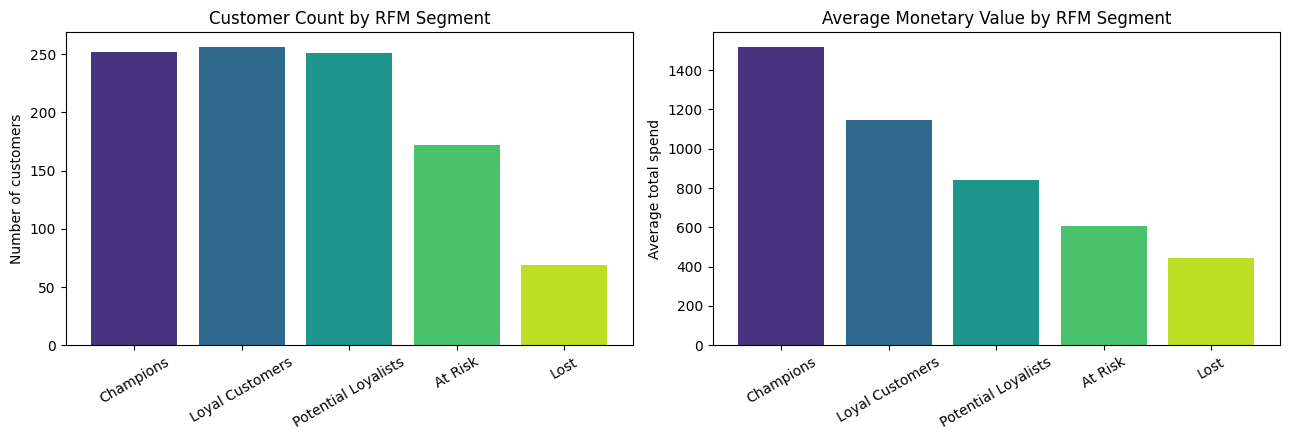

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

segment_order = segment_summary.index.tolist()
counts = rfm["rfm_segment"].value_counts().reindex(segment_order)
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(segment_order)))

axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title("Customer Count by RFM Segment")
axes[0].set_ylabel("Number of customers")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(segment_summary.index, segment_summary["avg_monetary"], color=colors)
axes[1].set_title("Average Monetary Value by RFM Segment")
axes[1].set_ylabel("Average total spend")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


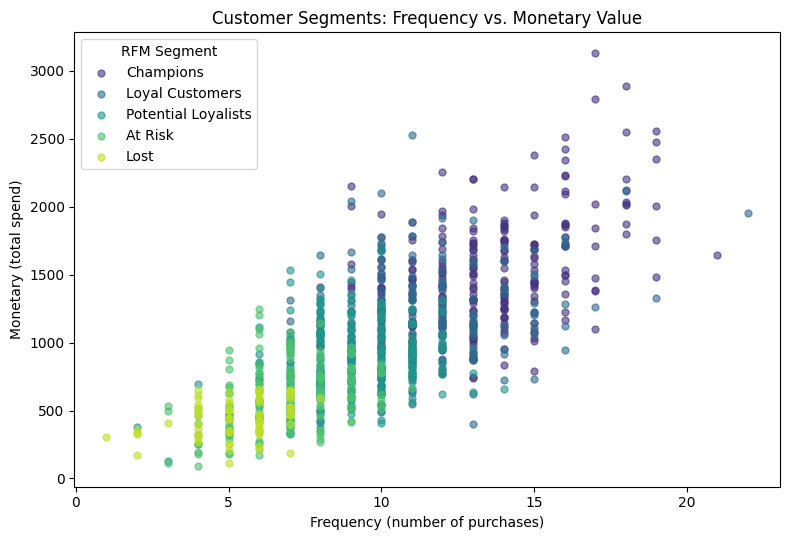

In [8]:
fig, ax = plt.subplots(figsize=(8, 5.5))
segment_colors = dict(zip(segment_order, colors))

for seg in segment_order:
    subset = rfm[rfm["rfm_segment"] == seg]
    ax.scatter(subset["frequency"], subset["monetary"], s=25, alpha=0.6,
               label=seg, color=segment_colors[seg])

ax.set_xlabel("Frequency (number of purchases)")
ax.set_ylabel("Monetary (total spend)")
ax.set_title("Customer Segments: Frequency vs. Monetary Value")
ax.legend(title="RFM Segment")
plt.tight_layout()
plt.show()


In [9]:
numeric_features = ["recency", "frequency", "avg_purchase_amount", "tenure_days"]
categorical_features = ["product_category", "payment_method", "customer_segment", "region"]
target = "monetary"

X = rfm[numeric_features + categorical_features]
y = rfm[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(transformers=[
    ("num", "passthrough", numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42),
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)

    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).set_index("Model").round(2)
results_df


,MAE,RMSE,R2
Model,,,
Linear Regression,74.43,110.57,0.94
Random Forest,26.99,58.60,0.98


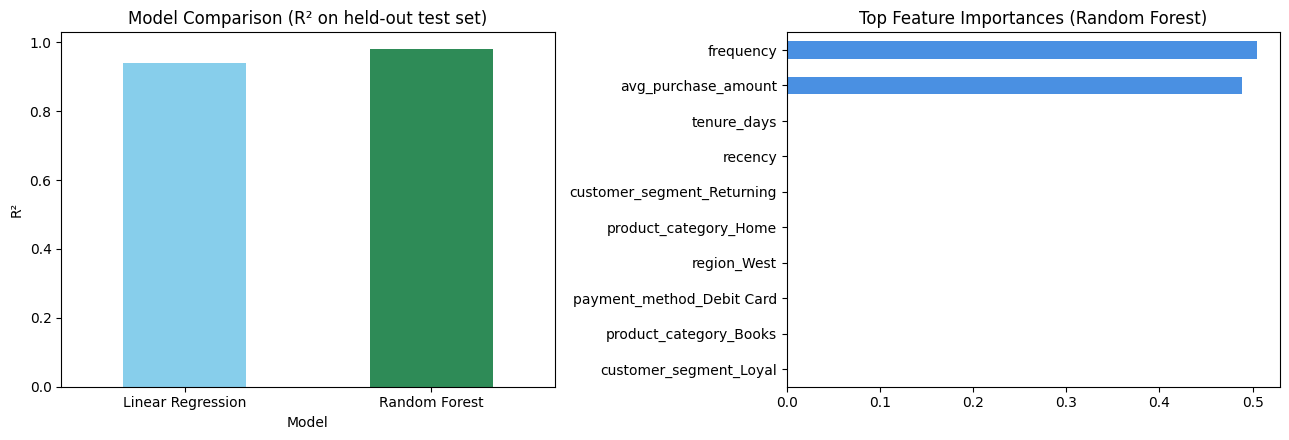

Best performing model on this dataset: Random Forest (R2 = 0.98)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

results_df["R2"].plot(kind="bar", ax=axes[0], color=["#87CEEB", "#2E8B57"])
axes[0].set_title("Model Comparison (R² on held-out test set)")
axes[0].set_ylabel("R²")
axes[0].tick_params(axis="x", rotation=0)

best_model_name = results_df["R2"].idxmax()
best_pipe = fitted_pipelines[best_model_name]

if best_model_name == "Random Forest":
    ohe_names = list(
        best_pipe.named_steps["preprocess"]
        .named_transformers_["cat"]
        .get_feature_names_out(categorical_features)
    )
    all_feature_names = numeric_features + ohe_names
    importances = best_pipe.named_steps["model"].feature_importances_
    imp_series = pd.Series(importances, index=all_feature_names).sort_values(ascending=True).tail(10)
    imp_series.plot(kind="barh", ax=axes[1], color="#4A90E2")
    axes[1].set_title(f"Top Feature Importances ({best_model_name})")
else:
    axes[1].axis("off")

plt.tight_layout()
plt.show()

print(f"Best performing model on this dataset: {best_model_name} (R2 = {results_df.loc[best_model_name, 'R2']})")


In [11]:
import os
os.makedirs("../artifacts", exist_ok=True)
rfm.to_csv("../artifacts/rfm_customer_segments.csv", index=False)
print("Saved customer-level RFM table with segments to ../artifacts/rfm_customer_segments.csv")


Saved customer-level RFM table with segments to ../artifacts/rfm_customer_segments.csv
